## Heart Disease Predictionâ€” Multiclass Classification

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, accuracy_score
import sys
import random
import tensorflow as tf

#import keras # Imported only for printing version info
#print(f'keras version: {keras.__version__}')
print(f'python version: {sys.version}')
print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'tensorflow version: {tf.__version__}')

# To get more consistent results, try to set the random seed:
random.seed(19)
np.random.seed(19)
tf.random.set_seed(19)

python version: 3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
numpy version: 2.1.3
pandas version: 2.3.3
tensorflow version: 2.20.0


In [53]:
# import the heart disease dataset
dataset = "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names =  ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','class']

# read the csv
dataset = pd.read_csv(dataset, names=column_names)

# remove missing data with "?"
df = dataset[~dataset.isin(['?'])]

#drop rows with NaN values from DataFrame
df = df.dropna(axis=0)

# checking data type of the dataframe
print (df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
class         int64
dtype: object


In [54]:
# transform data to numeric because ca and thal are object datatypes
data = df.apply(pd.to_numeric)
print(data.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
class         int64
dtype: object


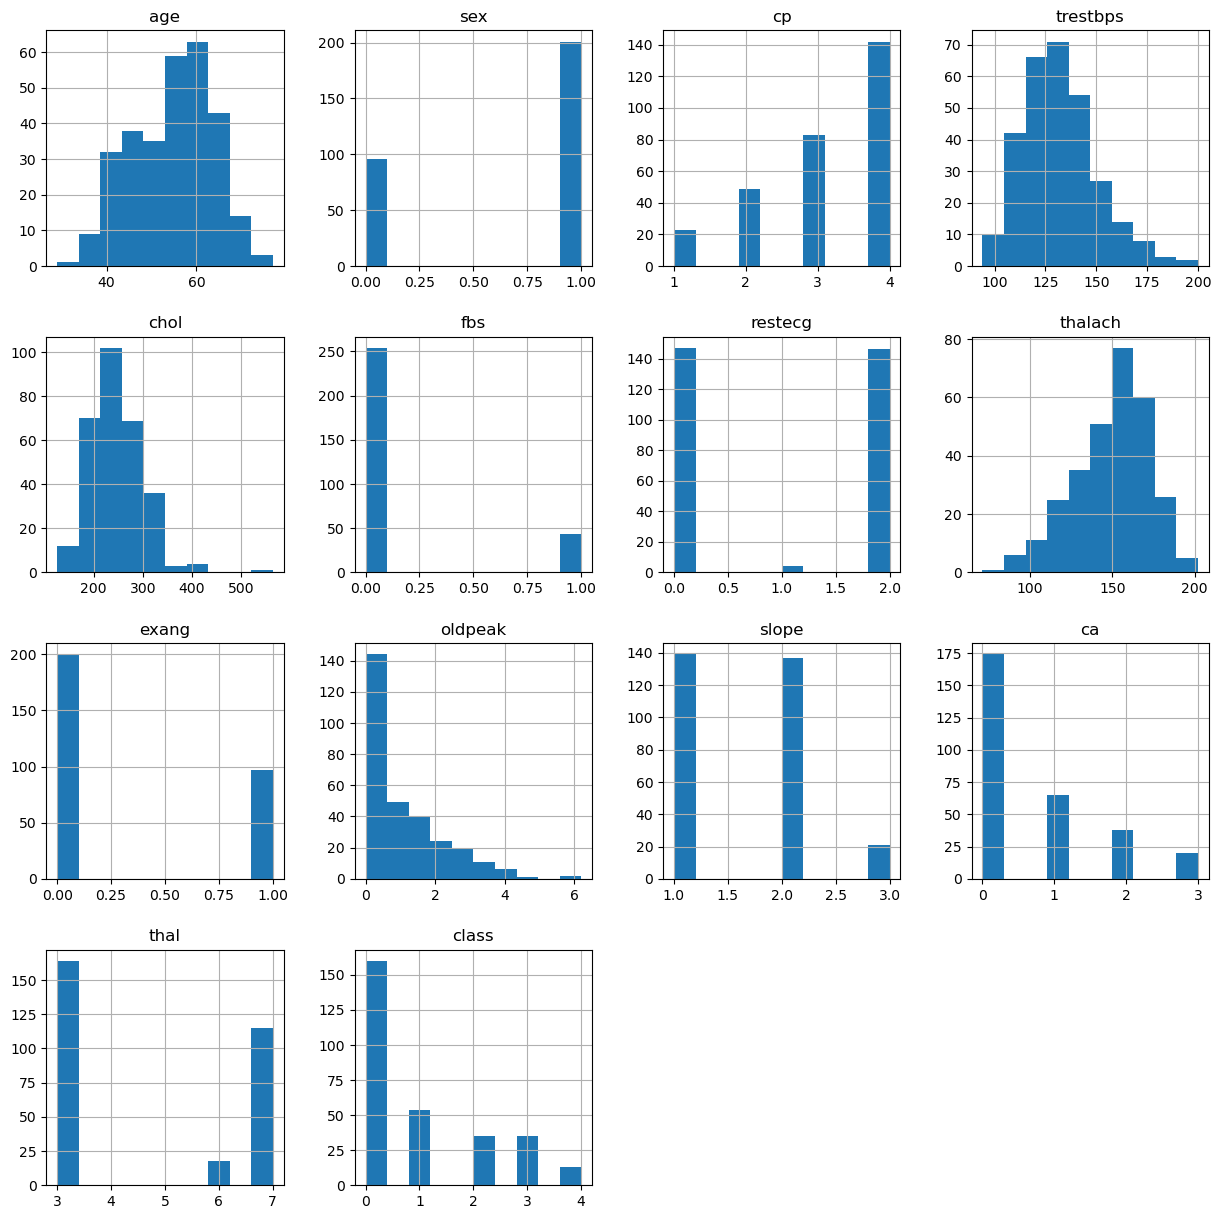

In [55]:
# plot histograms for each variable
data.hist(figsize = (15, 15))
plt.show()

In [56]:
# create X and Y datasets for training
X = data.iloc[:,0:13]
y = data.iloc[:,-1]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,shuffle = False, random_state=90)

# There are 4 classes so we need to one-hot encode them
# y_train = to_categorical(y_train)
# y_test = to_categorical(y_test)

# conversion to binary 
y_train = (y_train != 0).astype(int)
y_test = (y_test != 0).astype(int)

In [58]:
# create model
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(10, kernel_initializer='normal', activation='sigmoid'))
model.add(Dense(8, kernel_initializer='normal', activation='sigmoid'))
model.add(Dense(4, kernel_initializer='normal', activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

filepath="CNN_Model-{epoch:02d}-{val_accuracy:.2f}.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [59]:
# compile model
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [60]:
train_model = model.fit(X_train, y_train, epochs=60, batch_size=8, verbose = 1, validation_data=(X_test,y_test),callbacks=[callbacks_list])

Epoch 1/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 13s 473ms/step - accuracy: 0.2500 - loss: 0.8328
Epoch 1: val_accuracy improved from None to 0.51667, saving model to CNN_Model-01-0.52.h5



Epoch 1: finished saving model to CNN_Model-01-0.52.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4473 - loss: 0.7313 - val_accuracy: 0.5167 - val_loss: 0.6992
Epoch 2/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2500 - loss: 0.7788
Epoch 2: val_accuracy did not improve from 0.51667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4473 - loss: 0.7125 - val_accuracy: 0.5167 - val_loss: 0.6937
Epoch 3/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 0.7387
Epoch 3: val_accuracy did not improve from 0.51667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4473 - loss: 0.7008 - val_accuracy: 0.5167 - val_loss: 0.6922
Epoch 4/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2500 - loss: 0.7090
Epoch 4: val_accuracy did not improve from 0.51667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4810 - loss: 0.6938 - val_accuracy: 0.4833 - val_loss: 0.6929
Epoch 5/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 


Epoch 33: finished saving model to CNN_Model-33-0.53.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7131 - loss: 0.6286 - val_accuracy: 0.5333 - val_loss: 0.6669
Epoch 34/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5647
Epoch 34: val_accuracy improved from 0.53333 to 0.56667, saving model to CNN_Model-34-0.57.h5



Epoch 34: finished saving model to CNN_Model-34-0.57.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7595 - loss: 0.6239 - val_accuracy: 0.5667 - val_loss: 0.6645
Epoch 35/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5583
Epoch 35: val_accuracy improved from 0.56667 to 0.58333, saving model to CNN_Model-35-0.58.h5



Epoch 35: finished saving model to CNN_Model-35-0.58.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7764 - loss: 0.6192 - val_accuracy: 0.5833 - val_loss: 0.6619
Epoch 36/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.5516
Epoch 36: val_accuracy improved from 0.58333 to 0.63333, saving model to CNN_Model-36-0.63.h5


...


Epoch 37: finished saving model to CNN_Model-37-0.65.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8017 - loss: 0.6096 - val_accuracy: 0.6500 - val_loss: 0.6562
Epoch 38/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.5373
Epoch 38: val_accuracy improved from 0.65000 to 0.66667, saving model to CNN_Model-38-0.67.h5



Epoch 38: finished saving model to CNN_Model-38-0.67.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7806 - loss: 0.6046 - val_accuracy: 0.6667 - val_loss: 0.6531
Epoch 39/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5297
Epoch 39: val_accuracy improved from 0.66667 to 0.68333, saving model to CNN_Model-39-0.68.h5



Epoch 39: finished saving model to CNN_Model-39-0.68.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7932 - loss: 0.5996 - val_accuracy: 0.6833 - val_loss: 0.6499
Epoch 40/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5218
Epoch 40: val_accuracy did not improve from 0.68333
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7932 - loss: 0.5945 - val_accuracy: 0.6833 - val_loss: 0.6465
Epoch 41/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.5138
Epoch 41: val_accuracy did not improve from 0.68333
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.5894 - val_accuracy: 0.6833 - val_loss: 0.6432
Epoch 42/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.5057
Epoch 42: val_accuracy improved from 0.68333 to 0.70000, saving model to CNN_Model-42-0.70.h5



Epoch 42: finished saving model to CNN_Model-42-0.70.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.5843 - val_accuracy: 0.7000 - val_loss: 0.6397
Epoch 43/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.4975
Epoch 43: val_accuracy did not improve from 0.70000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.5791 - val_accuracy: 0.6833 - val_loss: 0.6363
Epoch 44/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.4892
Epoch 44: val_accuracy did not improve from 0.70000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.5740 - val_accuracy: 0.7000 - val_loss: 0.6328
Epoch 45/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.4809
Epoch 45: val_accuracy did not improve from 0.70000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.5688 - val_accuracy: 0.7000 - val_loss: 0.6292
Epoch 46/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - 


Epoch 52: finished saving model to CNN_Model-52-0.72.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8059 - loss: 0.5341 - val_accuracy: 0.7167 - val_loss: 0.6097
Epoch 53/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4177
Epoch 53: val_accuracy did not improve from 0.71667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8059 - loss: 0.5294 - val_accuracy: 0.7167 - val_loss: 0.6072
Epoch 54/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.4102
Epoch 54: val_accuracy did not improve from 0.71667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8059 - loss: 0.5248 - val_accuracy: 0.7167 - val_loss: 0.6051
Epoch 55/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4028
Epoch 55: val_accuracy did not improve from 0.71667
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8059 - loss: 0.5203 - val_accuracy: 0.7000 - val_loss: 0.6036
Epoch 56/60
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - 

In [61]:
# Plotting the model
plt.plot(train_model.history['accuracy'], marker='.')
plt.plot(train_model.history['val_accuracy'], marker='.')
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid()
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.savefig('model_accuracy.png')
plt.close()

plt.plot(train_model.history['loss'], marker='.')
plt.plot(train_model.history['val_loss'], marker='.')
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid()
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.savefig('model_loss.png')
plt.close()

In [62]:
pred = model.predict(X_test)

print('Maximum Probabilities of Test Dataset: ',np.max(pred, axis=-1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Maximum Probabilities of Test Dataset:  [0.26267585 0.26259768 0.26265275 0.31387064 0.27239046 0.62370694
 0.27261293 0.54215384 0.32695103 0.26385567 0.51481056 0.6806907
 0.66991127 0.26305962 0.26275572 0.2624961  0.2693519  0.29079214
 0.2645037  0.26792362 0.26353264 0.26576978 0.26260445 0.26260754
 0.6781955  0.5527815  0.515321   0.26361153 0.26292694 0.67436713
 0.6025782  0.6806135  0.27528876 0.26418227 0.28993067 0.26573
 0.2628093  0.2639234  0.26593554 0.59790945 0.26259512 0.6681891
 0.26219517 0.28278932 0.6814436  0.6797529  0.2658174  0.26265073
 0.36075717 0.2626559  0.57830876 0.68328375 0.26545447 0.25609553
 0.6835787  0.4402068  0.28133    0.67865914 0.67722887 0.26284337]


In [63]:
for i in pred:
    if(np.max(i) > 0.8):
        print("Critical")
    elif(np.max(i) > 0.5):
        print("moderate or severe")
    elif(np.max(i) > 0.3):
        print("mild or moderate")
    else:
        print("None")

None
None
None
mild or moderate
None
moderate or severe
None
moderate or severe
mild or moderate
None
moderate or severe
moderate or severe
moderate or severe
None
None
None
None
None
None
None
None
None
None
None
moderate or severe
moderate or severe
moderate or severe
None
None
moderate or severe
moderate or severe
moderate or severe
None
None
None
None
None
None
None
moderate or severe
None
moderate or severe
None
None
moderate or severe
moderate or severe
None
None
mild or moderate
None
moderate or severe
moderate or severe
None
None
moderate or severe
mild or moderate
None
moderate or severe
moderate or severe
None


In [64]:
# need to take argmax if it is a multiclass problem
# y_pred_argmax = np.argmax(pred, axis=1)
# y_test_argmax = np.argmax(y_test, axis=1)

# print('Classification Accuracy: '+str(accuracy_score(y_test_argmax, y_pred_argmax) * 100)+' %')

# binary accuracy
y_pred_binary = (pred > 0.5).astype(int)

print('Classification Accuracy: ' +
      str(accuracy_score(y_test, y_pred_binary) * 100) + ' %')

Classification Accuracy: 71.66666666666667 %
